In [1]:
#Plotting Figure 1

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Load saved arrays from Figure-1 Calc 
example_teca_LPS = xr.open_dataset("example_teca_LPS.nc")
example_teca_Front = xr.open_dataset("example_teca_Front.nc")
example_feat_LPS = xr.open_dataset("example_feat_LPS.nc")
example_feat_Front = xr.open_dataset("example_feat_Front.nc")


In [3]:
print(example_feat_Front)

<xarray.Dataset> Size: 431kB
Dimensions:          (time: 1, latitude: 241, longitude: 441)
Coordinates:
  * time             (time) datetime64[ns] 8B 2015-01-17T12:00:00
  * latitude         (latitude) float64 2kB 60.0 59.75 59.5 ... 0.5 0.25 0.0
  * longitude        (longitude) float64 4kB -160.0 -159.8 ... -50.25 -50.0
Data variables:
    feat_comb_label  (time, latitude, longitude) float32 425kB ...


In [4]:
print(example_teca_LPS.AR_event_category[0])

<xarray.DataArray 'AR_event_category' (latitude: 241, longitude: 441)> Size: 425kB
[106281 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 2kB 60.0 59.75 59.5 59.25 ... 0.5 0.25 0.0
  * longitude  (longitude) float64 4kB -160.0 -159.8 -159.5 ... -50.25 -50.0
    time       datetime64[ns] 8B 2015-06-15T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [5]:
#Function to calculate percentage contributions
def calc_percentages(data):
    """Calculate percentage occurrence of each label (excluding NaNs)."""
    data_flat = data.flatten()
    data_flat = data_flat[~np.isnan(data_flat)]  # remove NaNs

    # Remove zeros (no phenomena)
    data_flat = data_flat[data_flat != 0]
    unique, counts = np.unique(data_flat, return_counts=True)
    percentages = (counts / counts.sum()) * 100
    return unique, percentages


In [6]:
unique_LPS, percent_LPS = calc_percentages(example_feat_LPS.feat_comb_label[0].values)
unique_Front, percent_Front = calc_percentages(example_feat_Front.feat_comb_label[0].values)

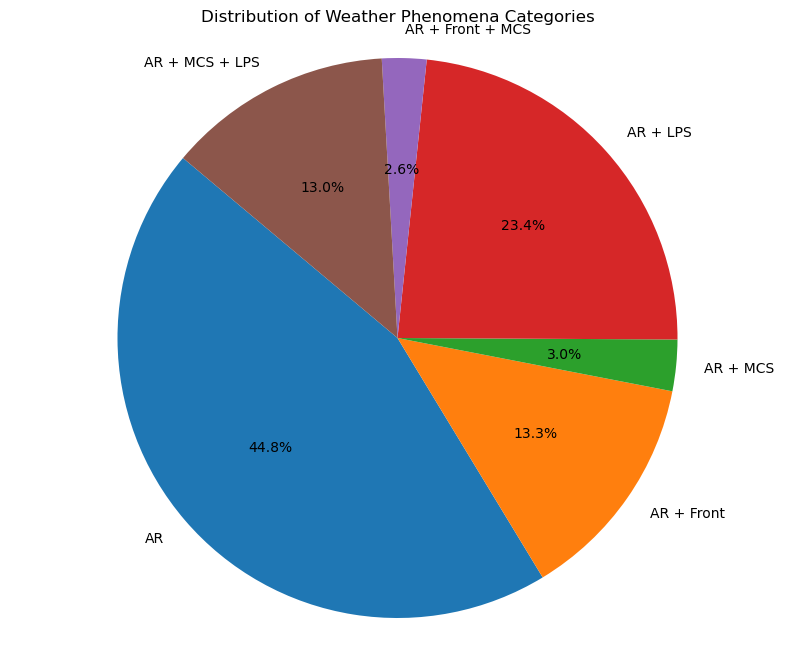

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Your label index mapping
label_index = {
    1: 'AR',
    2: 'Front',
    3: 'MCS',
    4: 'LPS',
    5: 'AR + Front',
    6: 'AR + MCS',
    7: 'AR + LPS',
    8: 'Front + MCS',
    9: 'Front + LPS',
    10: 'MCS + LPS',
    11: 'AR + Front + MCS',
    12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS',
    15: 'All'
}

# Map unique values to labels
labels = [label_index[int(cat)] for cat in unique_LPS]

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(percent_LPS, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Weather Phenomena Categories')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

In [8]:
import fsspec # for accessing remote data
import xarray as xr # for loading reanalysis data
import matplotlib as mpl # for plotting 
import matplotlib.pyplot as plt # also for plotting
import cartopy # for drawing maps on plots
import seaborn as sns # for making plot look pretty
import datetime as dt # for manipulating dates
import numpy as np # for doing math and working with arrays

# use seaborn to make the plots look nice
sns.set_theme(style = "whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
#Loading height lines from NCEP reanalysis data 
import datetime as dt

# Choose two specific dates
plot_dates = [
    dt.datetime(2015, 1, 17, 12),
    dt.datetime(2015, 6, 15, 18)
]

url_template = "https://downloads.psl.noaa.gov/Datasets/ncep.reanalysis/pressure/{variable}.{year}.nc"
variables = ["hgt"]

reanalysis_xr = None
file_handles = {var: {} for var in variables}

for var in variables:
    for date in plot_dates:
        print(date)
        if date.year not in file_handles[var]:
            file_handles[var][date.year] = fsspec.open(
                url_template.format(variable=var, year=date.year)
            )

        with file_handles[var][date.year] as f:
            tmp_xr = xr.open_dataset(f).sel(time=date)  # Select each date
            tmp_xr.load()

        if reanalysis_xr is None:
            reanalysis_xr = tmp_xr
        else:
            reanalysis_xr = xr.concat([reanalysis_xr, tmp_xr], dim="time")

reanalysis_xr


2015-01-17 12:00:00
2015-06-15 18:00:00


<xarray.Dataset> Size: 1MB
Dimensions:  (time: 2, level: 17, lat: 73, lon: 144)
Coordinates:
  * level    (level) float32 68B 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 16B 2015-01-17T12:00:00 2015-06-15T18:00:00
Data variables:
    hgt      (time, level, lat, lon) float32 1MB 79.0 79.0 ... 2.752e+04
Attributes:
    Conventions:    COARDS
    title:          4x daily NMC reanalysis (2014)
    history:        created 2013/12 by Hoop (netCDF2.3)
    description:    Data is from NMC initialized reanalysis\n(4x/day).  It co...
    platform:       Model
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

[1. 2. 3. 4. 5.]
[1. 2. 3. 4. 5.]


/global/homes/d/dkamnani/.conda/envs/climate_clean/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle'
  result = super().contour(*args, **kwargs)
/global/homes/d/dkamnani/.conda/envs/climate_clean/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle'
  result = super().contour(*args, **kwargs)


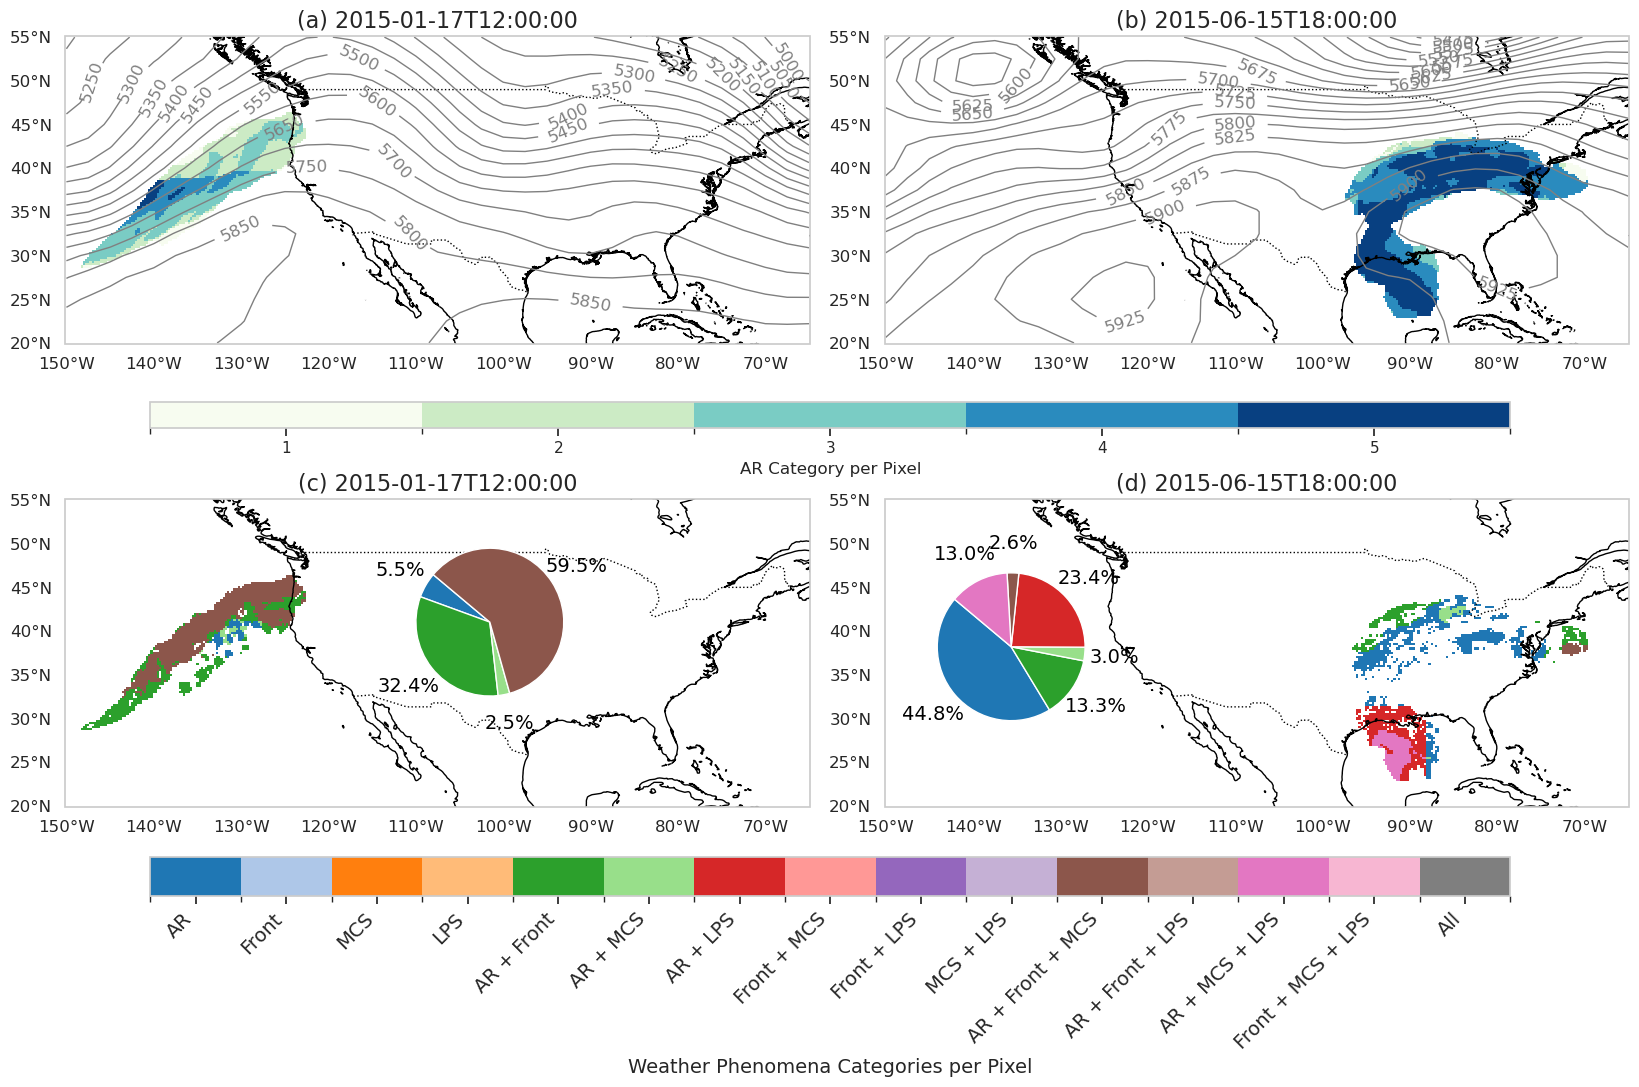

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Data ---
data1 = example_teca_Front.AR_event_category[0].sel(
    latitude=slice(55, 20), longitude=slice(-150, -65))
data3 = example_teca_LPS.AR_event_category[0].sel(
    latitude=slice(55, 20), longitude=slice(-150, -65))
data2 = example_feat_Front.feat_comb_label[0].sel(
    latitude=slice(55, 20), longitude=slice(-150, -65))
data4 = example_feat_LPS.feat_comb_label[0].sel(
    latitude=slice(55, 20), longitude=slice(-150, -65))

# 500 hPa height field
hgt_500 = reanalysis_xr['hgt'].sel(level=500)
hgt_500 = hgt_500.assign_coords(lon=(((hgt_500.lon + 180) % 360) - 180)).sortby('lon')
hgt_500 = hgt_500.sel(lat=slice(55, 20), lon=slice(-150, -65))

# Labels & colors
label_index = {1:'AR',2:'Front',3:'MCS',4:'LPS',5:'AR + Front',6:'AR + MCS',7:'AR + LPS',
               8:'Front + MCS',9:'Front + LPS',10:'MCS + LPS',11:'AR + Front + MCS',
               12:'AR + Front + LPS',13:'AR + MCS + LPS',14:'Front + MCS + LPS',15:'All'}
categories = np.arange(1, 16)
colors = plt.get_cmap('tab20').colors[:len(categories)]
color_dict = {cat: color for cat, color in zip(categories, colors)}

# -------------------------
# Function to add lat/lon values only
# -------------------------
def add_lat_lon_ticks(ax, lat_min=20, lat_max=55, lon_min=-150, lon_max=-65):
    ax.set_xticks(np.arange(lon_min, lon_max+1, 10), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(lat_min, lat_max+1, 5), crs=ccrs.PlateCarree())
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticklabels([f"{-1 * int(lon)}°W" for lon in np.arange(lon_min, lon_max+1, 10)])
    ax.set_yticklabels([f"{int(lat)}°N" for lat in np.arange(lat_min, lat_max+1, 5)])

# -------------------------
# Create figure
# -------------------------
fig = plt.figure(figsize=(17,13))
gs = gridspec.GridSpec(2, 2, height_ratios=[2,2], hspace=0.3)

# --- Top-left: AR + Front ---
#categories1 = np.arange(1, 8)
categories1 = np.unique(data1.values[~np.isnan(data1.values)])
categories1 = categories1[categories1 != 0]
print(categories1)
cmap1 = ListedColormap(plt.get_cmap('GnBu')(np.linspace(0,1,len(categories1))))
norm1 = BoundaryNorm(np.arange(0.5,len(categories1)+1.5,1), ncolors=cmap1.N, clip=False)

ax1 = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
data1.plot(ax=ax1, cmap=cmap1, norm=norm1, transform=ccrs.PlateCarree(), add_colorbar=False)
ax1.coastlines(resolution='10m', linewidth=1)
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.set_title("(a) 2015-01-17T12:00:00",fontsize = 16)
add_lat_lon_ticks(ax1)

# Overlay 500 hPa contours
contours1 = ax1.contour(hgt_500.lon, hgt_500.lat, hgt_500.isel(time=0).values,
                        levels=20, colors='grey', linestyle=":", linewidths=1,
                        transform=ccrs.PlateCarree())
ax1.clabel(contours1, inline=True, fontsize=12, fmt='%d')

# --- Top-right: AR + LPS ---
categories3 = np.unique(data3.values[~np.isnan(data3.values)])
categories3 = categories3[categories3 != 0]
print(categories3)
cmap3 = ListedColormap(plt.get_cmap('GnBu')(np.linspace(0,1,len(categories3))))
norm3 = BoundaryNorm(np.arange(-0.5,len(categories3)-0.5+1,1), ncolors=cmap3.N, clip=True)

ax3 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
data3.plot(ax=ax3, cmap=cmap3, norm=norm3, transform=ccrs.PlateCarree(), add_colorbar=False)
ax3.coastlines(resolution='10m', linewidth=1)
ax3.add_feature(cfeature.BORDERS, linestyle=':')
ax3.set_title("(b) 2015-06-15T18:00:00", fontsize = 16)
add_lat_lon_ticks(ax3)

# Overlay 500 hPa contours
contours3 = ax3.contour(hgt_500.lon, hgt_500.lat, hgt_500.isel(time=1).values,
                        levels=20, colors='grey', linestyle=":", linewidths=1,
                        transform=ccrs.PlateCarree())
ax3.clabel(contours3, inline=True, fontsize=12, fmt='%d')

# --- Bottom-left: AR + Front co-occurrence ---
data2_masked = data2.where(data2 != 0)
cmap_shared = ListedColormap([color_dict[i] for i in range(1,16)])
norm_shared = BoundaryNorm(np.arange(0.5,16.5,1), ncolors=15)

ax2 = fig.add_subplot(gs[1,0], projection=ccrs.PlateCarree())
data2_masked.plot(ax=ax2, cmap=cmap_shared, norm=norm_shared, transform=ccrs.PlateCarree(), add_colorbar=False)
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.set_title("(c) 2015-01-17T12:00:00", fontsize = 16)
add_lat_lon_ticks(ax2)

# --- Bottom-right: AR + LPS co-occurrence ---
data4_masked = data4.where(data4 != 0)

ax4 = fig.add_subplot(gs[1,1], projection=ccrs.PlateCarree())
data4_masked.plot(ax=ax4, cmap=cmap_shared, norm=norm_shared, transform=ccrs.PlateCarree(), add_colorbar=False)
ax4.coastlines()
ax4.add_feature(cfeature.BORDERS, linestyle=':')
ax4.set_title("(d) 2015-06-15T18:00:00",fontsize = 16)
add_lat_lon_ticks(ax4)

# --- Shared colorbars ---
cbar_ax_top = fig.add_axes([0.1,0.36,0.8,0.02])
sm_top = cm.ScalarMappable(norm=norm1, cmap=cmap1)
sm_top.set_array([])
cbar_top = plt.colorbar(sm_top, cax=cbar_ax_top, orientation='horizontal', ticks=[1,2,3,4,5])
cbar_top.set_label('AR Category per Pixel')

cbar_ax = fig.add_axes([0.1,0.00,0.8,0.03])
sm_shared = cm.ScalarMappable(norm=norm_shared, cmap=cmap_shared)
sm_shared.set_array([])
cbar = plt.colorbar(sm_shared, cax=cbar_ax, orientation='horizontal', ticks=np.arange(1,16))
cbar.ax.set_xticklabels([label_index[i] for i in range(1,16)], rotation=45, ha='right', fontsize=14)
cbar.set_label('Weather Phenomena Categories per Pixel', fontsize=14)

# --- Pie chart insets ---
# Bottom-left inset
ax_pie2 = inset_axes(ax2, width="60%", height="60%", loc='lower right',
                     bbox_to_anchor=(-0.13,0.3,1,1), bbox_transform=ax2.transAxes, borderpad=0)
wedges, texts, autotexts = ax_pie2.pie(percent_Front, autopct='%1.1f%%', startangle=140,
                                       colors=[color_dict[int(c)] for c in unique_Front],
                                       pctdistance=1.4, labeldistance=3.0)
for t in autotexts: t.set_fontsize(14); t.set_color("black")

# Bottom-right inset
ax_pie4 = inset_axes(ax4, width="60%", height="60%", loc='lower left',
                     bbox_to_anchor=(-0.13,0.22,1,1), bbox_transform=ax4.transAxes, borderpad=0)
wedges, texts, autotexts = ax_pie4.pie(percent_LPS, autopct='%1.1f%%', startangle=140,
                                       colors=[color_dict[int(c)] for c in unique_LPS],
                                       pctdistance=1.4, labeldistance=3.0)
for t in autotexts: t.set_fontsize(14); t.set_color("black")
# After plotting
ax1.set_xlabel('')
ax1.set_ylabel('')

ax3.set_xlabel('')
ax3.set_ylabel('')

ax2.set_xlabel('')
ax2.set_ylabel('')

ax4.set_xlabel('')
ax4.set_ylabel('')

# --- Layout adjustments & save ---
fig.subplots_adjust(top=0.68, bottom=0.05, left=0.05, right=0.97, hspace=0.05, wspace=0.10)
fig.savefig("AR_Front_LPS_maps_latlon_only.pdf", dpi=500, bbox_inches='tight')
plt.show()
